# **Phishing Website Detection by Machine Learning Techniques**

*Final project of AI & Cybersecurity Course*

## **1. Objective:**
A phishing website is a common social engineering method that mimics trustful uniform resource locators (URLs) and webpages. The objective of this project is to train machine learning models and deep neural nets on the dataset created to predict phishing websites. Both phishing and benign URLs of websites are gathered to form a dataset and from them required URL and website content-based features are extracted. The performance level of each model is measures and compared.

*This project is worked on Google Collaboratory.*<br>
*The required packages for this notebook are imported when needed.*

## **2. Loading Data:**

The features are extracted and store in the csv file. The working of this can be seen in the 'Phishing Website Detection_Feature Extraction.ipynb' file.

The reulted csv file is uploaded to this notebook and stored in the dataframe.

In [1]:
#importing basic packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data0 = pd.read_csv("DataFiles/Dataset89_terbaru.csv")
data0.head()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,label
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,0
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,1
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,3,...,1,0,0,14,4004,5828815,0,1,0,1
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,0
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,0


## **3. Familiarizing with Data**
In this step, few dataframe methods are used to look into the data and its features.

In [3]:
#Checking the shape of the dataset
data0.shape

(11430, 83)

In [4]:
#Listing the features of the dataset
data0.columns

Index(['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens',
       'nb_at', 'nb_qm', 'nb_and', 'nb_eq', 'nb_underscore', 'nb_tilde',
       'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma',
       'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com',
       'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url',
       'ratio_digits_host', 'punycode', 'port', 'tld_in_path',
       'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains',
       'prefix_suffix', 'random_domain', 'shortening_service',
       'path_extension', 'nb_redirection', 'nb_external_redirection',
       'length_words_raw', 'char_repeat', 'shortest_words_raw',
       'shortest_word_host', 'shortest_word_path', 'longest_words_raw',
       'longest_word_host', 'longest_word_path', 'avg_words_raw',
       'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand',
       'brand_in_subdomain', 'brand_in_path', 'suspecious_tld',
       'statistical_report', 'nb_hyper

In [5]:
#Information about the dataset
data0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 83 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  object 
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_eq                       11430 non-null  int64  
 10  nb_underscore               11430 non-null  int64  
 11  nb_tilde                    11430 non-null  int64  
 12  nb_percent                  11430 non-null  int64  
 13  nb_slash                    114

## **4. Visualizing the data**
Few plots and graphs are displayed to find how the data is distributed and the how features are related to each other.

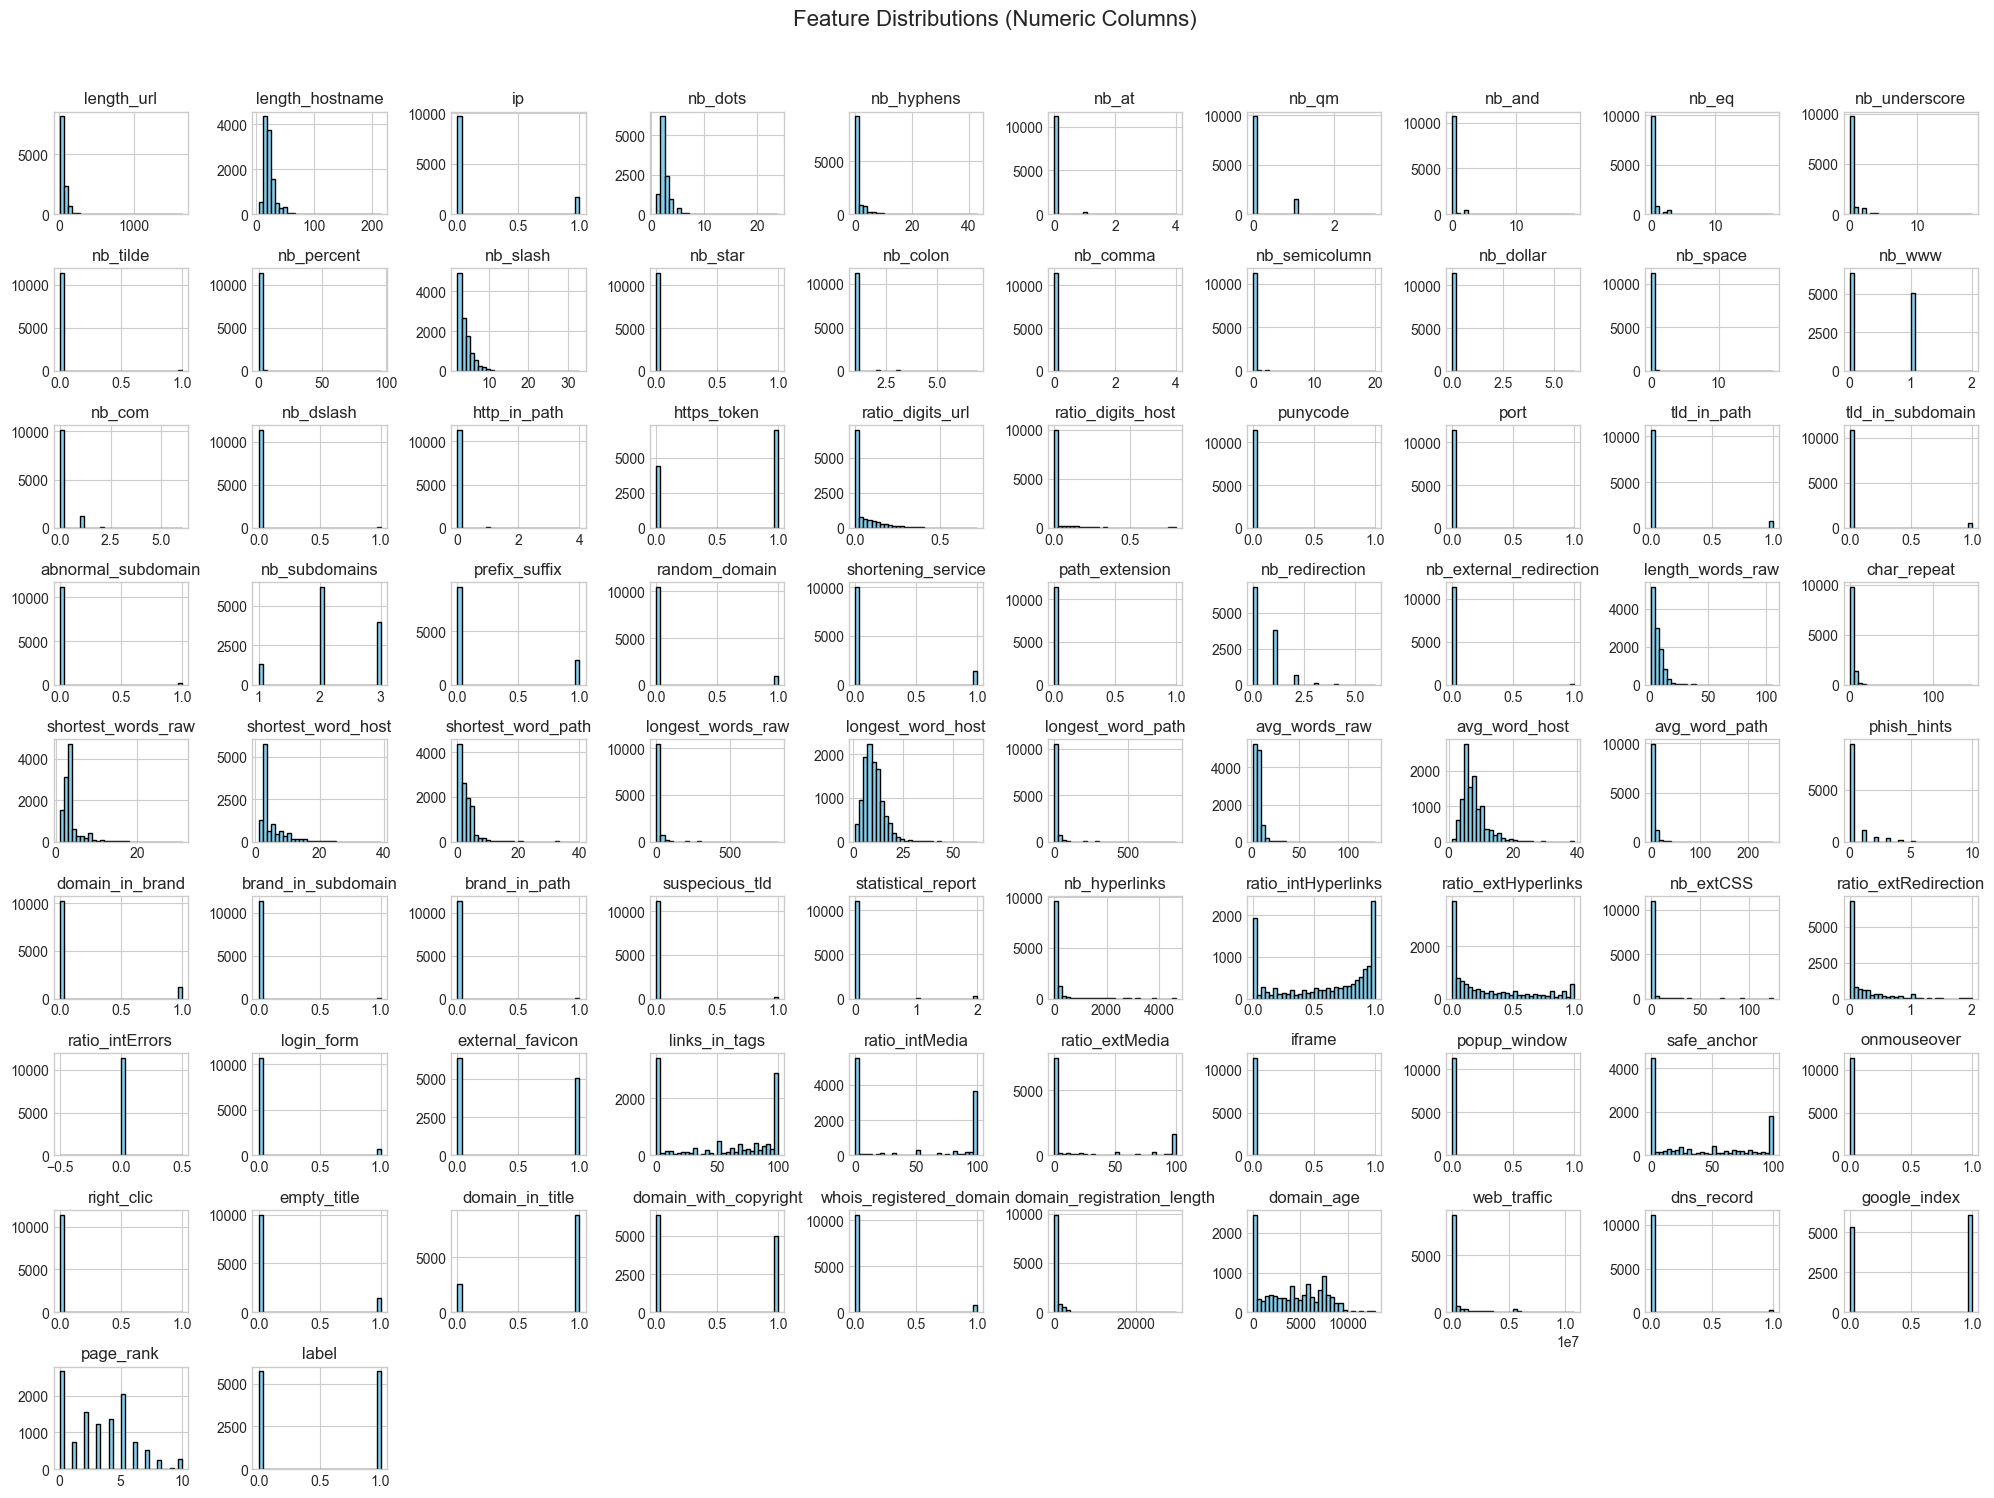

In [6]:
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

numeric_cols = data0.select_dtypes(include="number")
numeric_cols.hist(
    bins=30,
    figsize=(20, 16),
    color="skyblue",
    edgecolor="black",
    layout=(10, 10)
)
plt.suptitle("Feature Distributions (Numeric Columns)", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


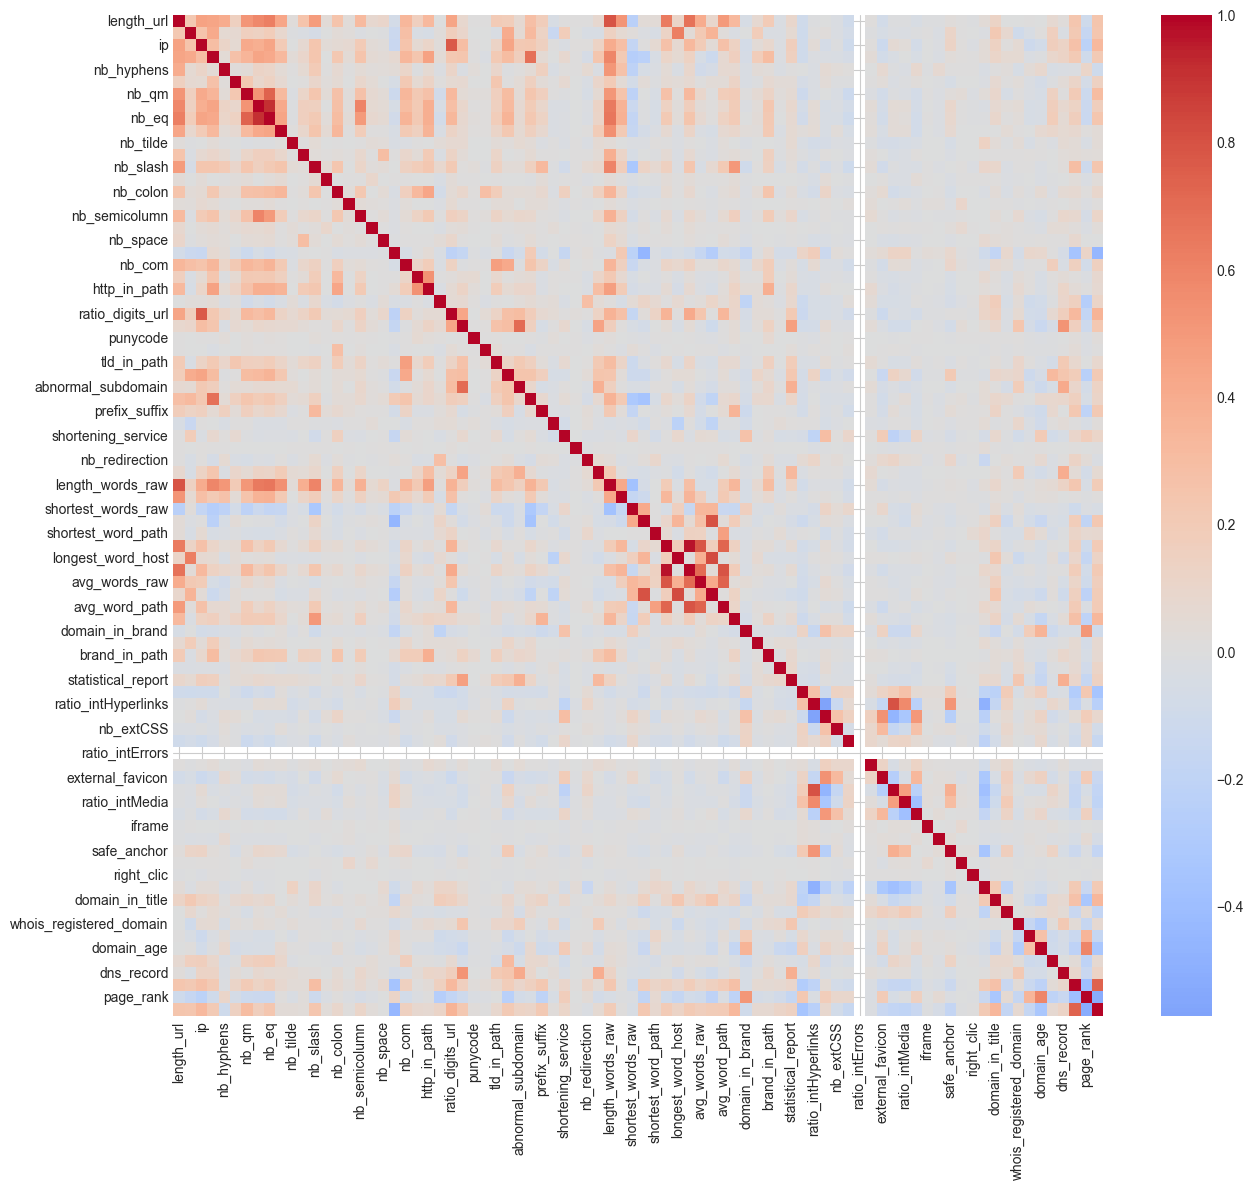

In [7]:
#Correlation heatmap
plt.figure(figsize=(15, 13))
corr = data0.select_dtypes(include="number").corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.show()

## **5. Data Preprocessing & EDA**
Here, we clean the data by applying data preprocesssing techniques and transform the data to use it in the models.

In [8]:
data0.describe()

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,nb_underscore,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,label
count,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,...,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,1.143000e+04,11430.000000,11430.000000,11430.000000,11430.000000
mean,61.126684,21.090289,0.150569,2.480752,0.997550,0.022222,0.141207,0.162292,0.293176,0.322660,...,0.775853,0.439545,0.072878,492.532196,4062.543745,8.567566e+05,0.020122,0.533946,3.185739,0.500000
std,55.297318,10.777171,0.357644,1.369686,2.087087,0.155500,0.364456,0.821337,0.998317,1.093336,...,0.417038,0.496353,0.259948,814.769415,3107.784600,1.995606e+06,0.140425,0.498868,2.536955,0.500022
min,12.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-1.000000,-12.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,33.000000,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,84.000000,972.250000,0.000000e+00,0.000000,0.000000,1.000000,0.000000
50%,47.000000,19.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,242.000000,3993.000000,1.651000e+03,0.000000,1.000000,3.000000,0.500000
75%,71.000000,24.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,449.000000,7026.750000,3.738455e+05,0.000000,1.000000,5.000000,1.000000
max,1641.000000,214.000000,1.000000,24.000000,43.000000,4.000000,3.000000,19.000000,19.000000,18.000000,...,1.000000,1.000000,1.000000,29829.000000,12874.000000,1.076799e+07,1.000000,1.000000,10.000000,1.000000


In [9]:
#Dropping the Domain column
data = data0.drop(['url'], axis=1).copy()

Setelah kolom `url` dihapus, dataset berisi seluruh fitur numerik dan kolom target (`Label`). Kolom bertipe numerik tetap dipakai apa adanya, termasuk fitur yang merepresentasikan kedalaman URL (jika ada), karena skalanya wajar untuk model.

In [10]:
#Dropping the Domain column
data = data0.drop(['url'], axis=1).copy()

# Hapus fitur zero-variance sesuai dokumen
zero_var_cols = [
    "nb_or",
    "ratio_nullHyperlinks",
    "ratio_intRedirection",
    "ratio_extErrors",
    "submit_email",
    "sfh"
]
data = data.drop(columns=[c for c in zero_var_cols if c in data.columns])

In [11]:
# cek apakah 6 kolom sudah tidak ada
[c for c in ["nb_or","ratio_nullHyperlinks","ratio_intRedirection","ratio_extErrors","submit_email","sfh"] if c in data.columns]

[]

In [12]:
#checking the data for null or missing values
data.isnull().sum()

length_url         0
length_hostname    0
ip                 0
nb_dots            0
nb_hyphens         0
                  ..
web_traffic        0
dns_record         0
google_index       0
page_rank          0
label              0
Length: 82, dtype: int64

Data dari phishing dan benign sudah digabung dalam satu dataset. Untuk mencegah pola urutan tertentu memengaruhi pembagian train-test, data diacak (shuffle) sebelum split. Ini membantu distribusi kelas di train/test lebih merata dan mengurangi risiko bias urutan.

In [13]:
# shuffling the rows in the dataset so that when splitting the train and test set are equally distributed
data = data.sample(frac=1).reset_index(drop=True)
data.head()

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,nb_underscore,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,label
0,238,19,1,14,0,0,1,3,4,0,...,0,0,0,2976,8346,1,0,0,10,1
1,73,25,0,3,0,0,0,0,0,0,...,1,0,0,655,1535,4641,0,1,2,1
2,53,30,0,3,1,0,0,0,0,0,...,0,1,0,302,5176,0,0,1,3,0
3,52,18,0,2,0,0,1,0,1,0,...,1,0,0,542,5301,0,0,1,0,1
4,30,22,0,2,0,0,0,0,0,0,...,1,1,0,34,5810,0,0,0,2,0


Dari hasil pengecekan, tidak ada nilai kosong (missing values) pada dataset. Dengan demikian, tahap pembersihan data dasar selesai dan data siap digunakan untuk pelatihan model.

## **6. Splitting the Data**

In [14]:
url_features = [
    "length_url", "length_hostname", "ip", "nb_dots", "nb_hyphens", "nb_at", "nb_qm", "nb_and",
    "nb_eq", "nb_underscore", "nb_tilde", "nb_percent", "nb_slash", "nb_star", "nb_colon",
    "nb_comma", "nb_semicolumn", "nb_dollar", "nb_space", "nb_www", "nb_com", "nb_dslash",
    "http_in_path", "https_token", "ratio_digits_url", "ratio_digits_host", "punycode", "port",
    "tld_in_path", "tld_in_subdomain", "abnormal_subdomain", "nb_subdomains", "prefix_suffix",
    "random_domain", "shortening_service", "path_extension", "nb_redirection"
]
X = data[url_features]
y = data['label']

In [15]:
# Splitting the dataset into train and test sets: 80-20 split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.2, random_state = 12)
X_train.shape, X_test.shape

((9144, 37), (2286, 37))

In [16]:
with open("feature_columns.txt", "w") as f:
    f.write("\n".join(X.columns))

## **7. Model Machine Learning & Pelatihan (Sesuai Dokumen TA)**

Berdasarkan dataset, ini adalah **supervised learning** untuk **klasifikasi**: URL diklasifikasikan sebagai **phishing (1)** atau **benign (0)**.  
Sistem yang dibangun mengikuti pendekatan **hybrid** pada dokumen, yaitu:

1. **Rule-Based Filtering** sebagai lapisan awal untuk deteksi cepat (pre-filter).
2. **Model Machine Learning**:
   * **Random Forest (RF)**
   * **XGBoost (XGB)**
3. **Stacking Ensemble**:
   * RF dan XGB sebagai **base learners**
   * **Logistic Regression** sebagai **meta-learner**

Fokus evaluasi menggunakan metrik: **accuracy, precision, recall, F1-score, dan AUC**.

### **7.1. Rule-Based Filtering (Pre-filter)**
Rule-based filtering digunakan sebagai lapisan awal untuk mendeteksi indikasi phishing secara cepat berdasarkan pola URL yang mencurigakan.  
Pada tahap ini, aturan dibangun dari fitur-fitur URL yang memiliki pola eksplisit (misal karakter khusus, struktur domain, dan TLD mencurigakan).  
Tujuannya adalah memberikan **skor/flag awal** sebelum data masuk ke model machine learning.  
Fitur yang bersifat statistik/rasio tetap diproses oleh model ML karena lebih efektif dipelajari secara non-linear.


In [17]:
import re, math, ipaddress
from urllib.parse import urlparse
import tldextract
import pandas as pd
import numpy as np

# ====== RULE-BASED (DATASET) ======
y_true = data["label"]
X = data.drop(columns=["label"])

df_rules = X.copy()

def _col(c):
    return df_rules[c] if c in df_rules.columns else 0

# Buat dict Series untuk setiap kategori
very_important = {
    "suspecious_tld": (_col("suspecious_tld") == 1),
    "nb_at": (_col("nb_at") >= 1),
    "ip": (_col("ip") == 1),
    "nb_underscore": (_col("nb_underscore") > 3),
}

important = {
    "ratio_digits_url": (_col("ratio_digits_url") > 0.3),
    "nb_subdomains": (_col("nb_subdomains") > 3),
    "nb_percent": (_col("nb_percent") > 5),
    "nb_tilde": (_col("nb_tilde") >= 1),
    "nb_semicolumn": (_col("nb_semicolumn") >= 1),
    "nb_star": (_col("nb_star") >= 1),
    "nb_comma": (_col("nb_comma") >= 1),
    "random_domain": (_col("random_domain") == 1),
}

less_important = {
    "length_hostname": (_col("length_hostname") > 30),
    "nb_dollar": (_col("nb_dollar") >= 1),
    "nb_qm": (_col("nb_qm") > 2),
    "nb_colon": (_col("nb_colon") > 1),
    "nb_eq": (_col("nb_eq") > 8),
    "nb_dots": (_col("nb_dots") > 4),
    "nb_slash": (_col("nb_slash") > 7),
    "nb_and": (_col("nb_and") > 3),
    "nb_hyphens": (_col("nb_hyphens") > 3),
    "http_in_path": (_col("http_in_path") == 1),
    "https_token": (_col("https_token") == 1),
    "port": (_col("port") == 1),
    "shortening_service": (_col("shortening_service") == 1),
}

# Perhitungan flag per baris (per URL)
vi_count = pd.DataFrame(very_important).astype(int).sum(axis=1)
imp_count = pd.DataFrame(important).astype(int).sum(axis=1)
less_count = pd.DataFrame(less_important).astype(int).sum(axis=1)

rule1_flag = (vi_count >= 2)
risk_score = (3 * vi_count) + (2 * imp_count) + (1 * less_count)

rule_flag = ((rule1_flag) | (risk_score >= 7)).astype(int)

risk_category = np.select(
    [
        rule_flag == 1,
        (risk_score >= 4) & (risk_score <= 6),
        (risk_score >= 1) & (risk_score <= 3),
        risk_score == 0,
    ],
    ["Phishing", "Suspicious", "Caution", "Benign"],
    default="Unknown",
)

print("Rule-based ready. Contoh distribusi kategori:")
print(pd.Series(risk_category).value_counts())

# ====== UTIL FUNCTIONS (URL BARU) ======
SHORTENERS = [
    "bit.ly", "goo.gl", "tinyurl.com", "ow.ly", "t.co", "is.gd", "buff.ly",
    "adf.ly", "bit.do", "cutt.ly"
]

SUSPICIOUS_TLD = ["zip","xyz","top","tk","ga","ml","gq","cf","pw","cc","club"]

def entropy(s):
    if not s:
        return 0
    probs = [s.count(c)/len(s) for c in set(s)]
    return -sum(p * math.log2(p) for p in probs)

def extract_features(url):
    parsed = urlparse(url)
    hostname = parsed.hostname or ""
    path = parsed.path or ""
    full = url

    ext = tldextract.extract(url)
    domain = ext.domain
    subdomain = ext.subdomain

    nb_digits = sum(c.isdigit() for c in full)
    ratio_digits_url = nb_digits / max(len(full),1)

    nb_subdomains = len(subdomain.split(".")) if subdomain else 0

    try:
        ipaddress.ip_address(hostname)
        ip_flag = 1
    except:
        ip_flag = 0

    random_domain = 1 if entropy(domain) > 3.5 else 0

    features = {
        "suspecious_tld": 1 if ext.suffix in SUSPICIOUS_TLD else 0,
        "nb_at": full.count("@"),
        "ip": ip_flag,
        "nb_underscore": full.count("_"),
        "ratio_digits_url": ratio_digits_url,
        "nb_subdomains": nb_subdomains,
        "nb_percent": full.count("%"),
        "nb_tilde": full.count("~"),
        "nb_semicolumn": full.count(";"),
        "nb_star": full.count("*"),
        "nb_comma": full.count(","),
        "random_domain": random_domain,
        "length_hostname": len(hostname),
        "nb_dollar": full.count("$"),
        "nb_qm": full.count("?"),
        "nb_colon": full.count(":"),
        "nb_eq": full.count("="),
        "nb_dots": full.count("."),
        "nb_slash": full.count("/"),
        "nb_and": full.count("&"),
        "nb_hyphens": full.count("-"),
        "http_in_path": 1 if "http" in path else 0,
        "https_token": 1 if "https" in full.replace("https://", "") else 0,
        "port": 1 if parsed.port else 0,
        "shortening_service": 1 if any(s in hostname for s in SHORTENERS) else 0,
    }
    return features

def rule_based_eval(feats):
    very_important = {
        "suspecious_tld": (feats["suspecious_tld"] == 1),
        "nb_at": (feats["nb_at"] >= 1),
        "ip": (feats["ip"] == 1),
        "nb_underscore": (feats["nb_underscore"] > 3),
    }

    important = {
        "ratio_digits_url": (feats["ratio_digits_url"] > 0.3),
        "nb_subdomains": (feats["nb_subdomains"] > 3),
        "nb_percent": (feats["nb_percent"] > 5),
        "nb_tilde": (feats["nb_tilde"] >= 1),
        "nb_semicolumn": (feats["nb_semicolumn"] >= 1),
        "nb_star": (feats["nb_star"] >= 1),
        "nb_comma": (feats["nb_comma"] >= 1),
        "random_domain": (feats["random_domain"] == 1),
    }

    less_important = {
        "length_hostname": (feats["length_hostname"] > 30),
        "nb_dollar": (feats["nb_dollar"] >= 1),
        "nb_qm": (feats["nb_qm"] > 2),
        "nb_colon": (feats["nb_colon"] > 1),
        "nb_eq": (feats["nb_eq"] > 8),
        "nb_dots": (feats["nb_dots"] > 4),
        "nb_slash": (feats["nb_slash"] > 7),
        "nb_and": (feats["nb_and"] > 3),
        "nb_hyphens": (feats["nb_hyphens"] > 3),
        "http_in_path": (feats["http_in_path"] == 1),
        "https_token": (feats["https_token"] == 1),
        "port": (feats["port"] == 1),
        "shortening_service": (feats["shortening_service"] == 1),
    }

    vi_count = sum(int(v) for v in very_important.values())
    imp_count = sum(int(v) for v in important.values())
    less_count = sum(int(v) for v in less_important.values())

    rule1_flag = (vi_count >= 2)
    risk_score = (3 * vi_count) + (2 * imp_count) + (1 * less_count)

    rule_flag = int(rule1_flag or (risk_score >= 7))
    risk_category = np.select(
        [
            rule_flag == 1,
            (risk_score >= 4) & (risk_score <= 6),
            (risk_score >= 1) & (risk_score <= 3),
            risk_score == 0,
        ],
        ["Phishing", "Suspicious", "Caution", "Benign"],
        default="Unknown",
    )

    return risk_score, risk_category, rule_flag

def predict_url(url):
    feats = extract_features(url)
    score, category, flag = rule_based_eval(feats)
    return score, category, flag

# daftar URL baru
urls = [
    "http://secure-paypal-login-verify.xyz/index.php?user=abc",
    "https://www.google.com",
    "http://bit.ly/abc123"
]

results = []
for u in urls:
    score, category, flag = predict_url(u)
    results.append({
        "url": u,
        "risk_score": score,
        "category": category,
        "flag": "Phishing" if flag == 1 else "Legit"
    })

df_results = pd.DataFrame(results)
df_results

Rule-based ready. Contoh distribusi kategori:
Caution       6786
Benign        2408
Suspicious    1769
Phishing       467
Name: count, dtype: int64


,url,risk_score,category,flag
0,http://secure-paypal-login-verify.xyz/index.ph...,5,Suspicious,Legit
1,https://www.google.com,0,Benign,Legit
2,http://bit.ly/abc123,1,Caution,Legit


In [18]:
rule_flag = ((rule1_flag) | (risk_score >= 7)).astype(int)

from sklearn.metrics import confusion_matrix

y_true = data["label"]  # 1=phishing, 0=benign
y_pred = rule_flag

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print("TP:", tp)
print("FP:", fp)
print("FN:", fn)
print("TN:", tn)

TP: 440
FP: 27
FN: 5275
TN: 5688


### **7.2. Evaluasi & Persiapan Metrik**
Setelah rule‑based menghasilkan `rule_flag`, tahap berikutnya adalah menyiapkan metrik evaluasi untuk membandingkan performa rule‑based dan model ML yang akan dilatih.

In [19]:
# importing packages
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
    
)

In [20]:
y_true = data["label"]
y_pred = rule_flag

acc_rb = accuracy_score(y_true, y_pred)
prec_rb = precision_score(y_true, y_pred, zero_division=0)
rec_rb = recall_score(y_true, y_pred, zero_division=0)
f1_rb = f1_score(y_true, y_pred, zero_division=0)
auc_rb = roc_auc_score(y_true, risk_score)

print("Rule-Based -> Acc:", round(acc_rb, 3),
      "| Prec:", round(prec_rb, 3),
      "| Recall:", round(rec_rb, 3),
      "| F1:", round(f1_rb, 3),
      "| AUC:", round(auc_rb, 3))

Rule-Based -> Acc: 0.536 | Prec: 0.942 | Recall: 0.077 | F1: 0.142 | AUC: 0.716


In [21]:
# Creating holders to store the model performance results
ML_Model = []
acc_train = []
acc_test = []
prec_test = []
recall_test = []
f1_test = []
auc_test = []

# function to call for storing the results
def storeResults(model, a_tr, a_te, p=None, r=None, f=None, auc=None):
    ML_Model.append(model)
    acc_train.append(round(a_tr, 3))
    acc_test.append(round(a_te, 3))
    prec_test.append(np.nan if p is None else round(p, 3))
    recall_test.append(np.nan if r is None else round(r, 3))
    f1_test.append(np.nan if f is None else round(f, 3))
    auc_test.append(np.nan if auc is None else round(auc, 3))

### **7.3. Random Forest (RF)**  
Random Forest adalah ensemble dari banyak decision tree yang dilatih pada subset data dan fitur secara acak.  
Pendekatan ini meningkatkan stabilitas model dan mengurangi overfitting dibanding pohon tunggal.  
Pada penelitian ini, Random Forest digunakan sebagai **base learner** dalam skema stacking bersama XGBoost.

In [22]:
# Random Forest model
from sklearn.ensemble import RandomForestClassifier

# instantiate the model
forest = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=12, n_jobs=-1)

# fit the model
forest.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
# predicting the target value from the model for the samples
y_test_forest = forest.predict(X_test)
y_train_forest = forest.predict(X_train)

**Performance Evaluation:**

In [24]:
#computing the accuracy of the model performance
acc_train_forest = accuracy_score(y_train, y_train_forest)
acc_test_forest = accuracy_score(y_test, y_test_forest)

print("Random Forest: Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random Forest: Accuracy on test Data: {:.3f}".format(acc_test_forest))

Random Forest: Accuracy on training Data: 0.812
Random Forest: Accuracy on test Data: 0.818


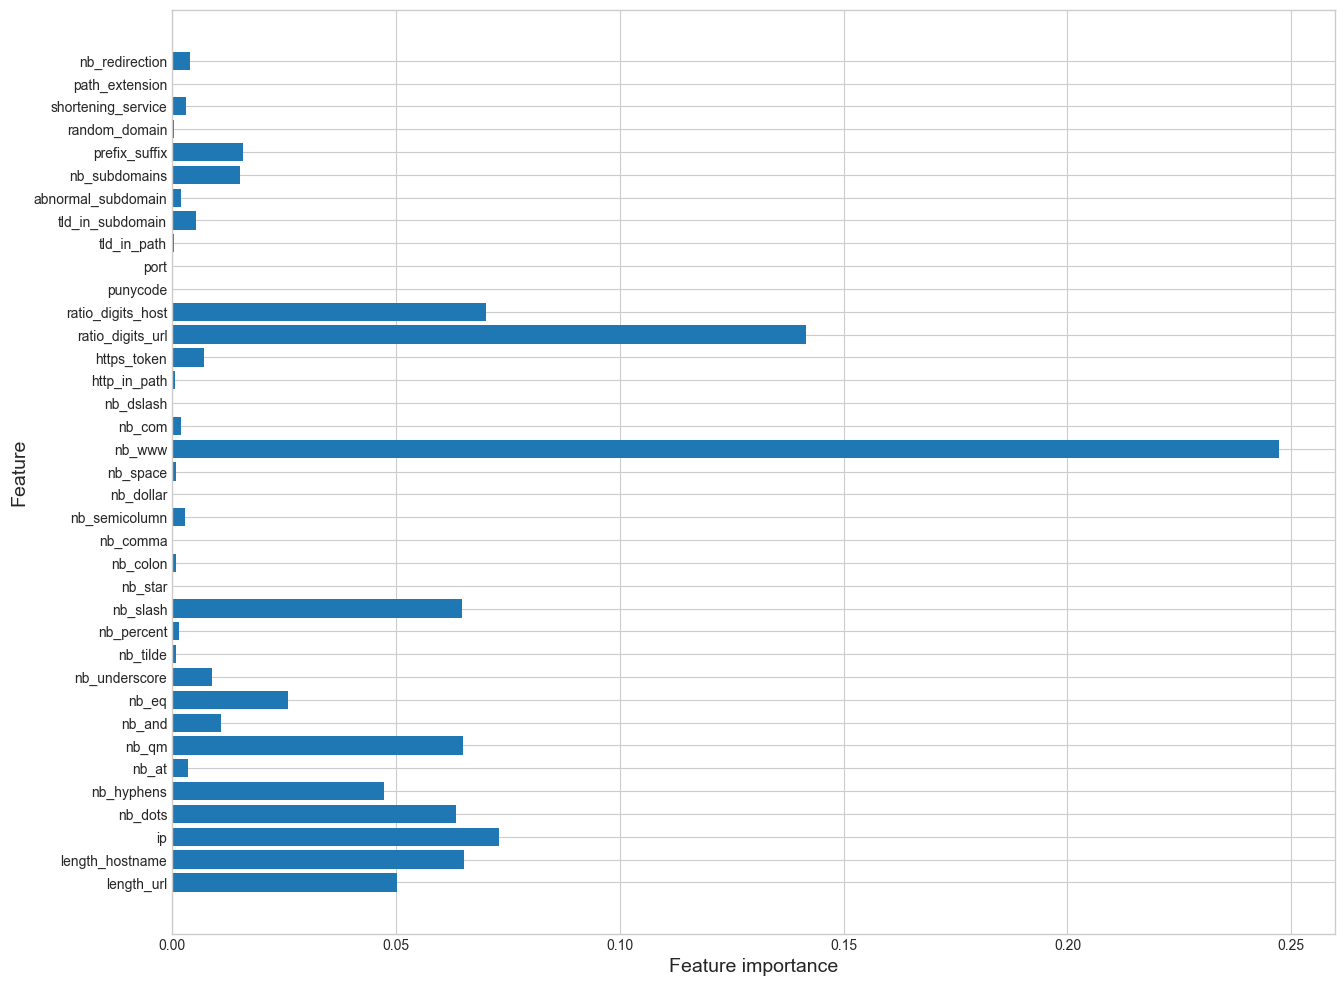

In [25]:
#checking the feature importance in the model
plt.figure(figsize=(15, 12)) 
n_features = X_train.shape[1]
plt.barh(range(n_features), forest.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns, fontsize=10)  # Mengatur ukuran font agar lebih jelas
plt.xlabel("Feature importance", fontsize=14)  # Ukuran font label sumbu X
plt.ylabel("Feature", fontsize=14)  # Ukuran font label sumbu Y
plt.show()

**Storing the results:**

In [26]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Random Forest', acc_train_forest, acc_test_forest)

### **7.2. XGBoost Classifier**
XGBoost (eXtreme Gradient Boosting) adalah algoritma machine learning yang sangat populer dan banyak digunakan untuk tugas klasifikasi dan regresi. XGBoost merupakan implementasi dari teknik gradient boosting yang menggabungkan beberapa pohon keputusan untuk membuat prediksi yang lebih akurat. Teknik ini membangun model secara bertahap, di mana setiap pohon keputusan yang baru dirancang untuk mengoreksi kesalahan yang dilakukan oleh pohon keputusan sebelumnya.

Keunggulan utama XGBoost terletak pada kecepatan dan performa yang sangat tinggi, yang menjadikannya sangat efisien dalam menangani dataset besar dan kompleks. Salah satu fitur unggulan XGBoost adalah regularisasi, yang berfungsi untuk mengurangi risiko overfitting—suatu kondisi di mana model terlalu menyesuaikan diri dengan data pelatihan sehingga tidak dapat beradaptasi dengan baik pada data baru. Dengan regularisasi ini, XGBoost dapat menghasilkan model yang lebih stabil dan generalis.

XGBoost juga mendukung paralelisasi proses pembelajaran, yang berarti dapat menjalankan proses pelatihan dengan lebih cepat, terutama pada data yang sangat besar. Selain itu, XGBoost mampu mengelola atribut yang tidak relevan atau berisik (noise) dalam dataset dengan sangat baik, yang sering kali menjadi tantangan dalam model-model lainnya

In [27]:
# XGBoost Classification model
from xgboost import XGBClassifier

# instantiate the model (lebih konservatif untuk kurangi overfitting)
xgb = XGBClassifier(
    n_estimators=200,        # nrounds
    learning_rate=0.1,       # eta
    max_depth=4,             # maxdepth
    reg_lambda=1.0,          # lambda
    reg_alpha=0.1,           # alpha
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    min_child_weight=2,
    random_state=12,
    n_jobs=-1,
    eval_metric="logloss"
)

# fit the model
xgb.fit(X_train, y_train)

# predicting the target value from the model for the samples
y_test_xgb = xgb.predict(X_test)
y_train_xgb = xgb.predict(X_train)

**Performance Evaluation:**

In [28]:
#computing the accuracy of the model performance
acc_train_xgb = accuracy_score(y_train,y_train_xgb)
acc_test_xgb = accuracy_score(y_test,y_test_xgb)

print("XGBoost: Accuracy on training Data: {:.3f}".format(acc_train_xgb))
print("XGBoost : Accuracy on test Data: {:.3f}".format(acc_test_xgb))

XGBoost: Accuracy on training Data: 0.897
XGBoost : Accuracy on test Data: 0.885


In [29]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import cross_val_score

# 1) Metrik tambahan
print(classification_report(y_test, y_test_xgb, digits=3))
print(confusion_matrix(y_test, y_test_xgb))
print("AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]))

# 2) Cross-validation (cek generalisasi)
cv_scores = cross_val_score(xgb, X, y, cv=5, scoring="accuracy")
print("CV Accuracy:", cv_scores.mean().round(3), "+/-", cv_scores.std().round(3))

# 3) Cek leakage sederhana
print("Label in X columns?", "label" in X.columns)

              precision    recall  f1-score   support

           0      0.889     0.879     0.884      1137
           1      0.881     0.891     0.886      1149

    accuracy                          0.885      2286
   macro avg      0.885     0.885     0.885      2286
weighted avg      0.885     0.885     0.885      2286

[[ 999  138]
 [ 125 1024]]
AUC: 0.9514495033347035
CV Accuracy: 0.968 +/- 0.005
Label in X columns? False


**Storing the results:**

In [30]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('XGBoost', acc_train_xgb, acc_test_xgb)

In [31]:
# Stacking Ensemble (RF + XGB -> Logistic Regression)
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

base_learners = [
    ("rf", forest),
    ("xgb", xgb),
]

meta_learner = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=12)

stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    stack_method="predict_proba",
    n_jobs=-1
)

stack_model.fit(X_train, y_train)

y_test_stack = stack_model.predict(X_test)
y_train_stack = stack_model.predict(X_train)

acc_train_stack = accuracy_score(y_train, y_train_stack)
acc_test_stack = accuracy_score(y_test, y_test_stack)

print("Stacking: Accuracy on training Data: {:.3f}".format(acc_train_stack))
print("Stacking: Accuracy on test Data: {:.3f}".format(acc_test_stack))

storeResults("Stacking (RF+XGB+LR)", acc_train_stack, acc_test_stack)

Stacking: Accuracy on training Data: 0.899
Stacking: Accuracy on test Data: 0.883


## **8. Comparision of Models**
To compare the models performance, a dataframe is created. The columns of this dataframe are the lists created to store the results of the model.

In [32]:
#creating dataframe
results = pd.DataFrame({ 'ML Model': ML_Model,    
    'Train Accuracy': acc_train,
    'Test Accuracy': acc_test})
results

,ML Model,Train Accuracy,Test Accuracy
0,Random Forest,0.812,0.818
1,XGBoost,0.897,0.885
2,Stacking (RF+XGB+LR),0.899,0.883


In [33]:
#Sorting the datafram on accuracy
results.sort_values(by=['Test Accuracy', 'Train Accuracy'], ascending=False)

,ML Model,Train Accuracy,Test Accuracy
1,XGBoost,0.897,0.885
2,Stacking (RF+XGB+LR),0.899,0.883
0,Random Forest,0.812,0.818


For the above comparision, it is clear that the XGBoost Classifier works well with this dataset.

So, saving the model for future use.

In [34]:
# save XGBoost model to file
import pickle
pickle.dump(xgb, open("xgboost_model.pkl", "wb"))

**Testing the saved model:**

In [36]:
loaded_model = pickle.load(open("xgboost_model.pkl", "rb"))
loaded_model

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## **9. References**
* https://blog.keras.io/building-autoencoders-in-keras.html
* https://en.wikipedia.org/wiki/Autoencoder
* https://mc.ai/a-beginners-guide-to-build-stacked-autoencoder-and-tying-weights-with-it/
* https://github.com/shreyagopal/t81_558_deep_learning/blob/master/t81_558_class_14_03_anomaly.ipynb
* https://machinelearningmastery.com/save-gradient-boosting-models-xgboost-python/